# Full Odra state fidelity — 5-fold CV × depths 2 / 4 / 6

Runs hardware state tomography on IQM Spark for **both ansatze** (Ring simulator-opt, Odra hardware-opt) across **all cross-validation folds** and **depths 2, 4, 6**.

Uses pilot-calibrated settings (`shots=1024`, `n_samples=10` per fold) from `scripts/pilot_state_fidelity.py`.

**Resume:** results append to `iqm_fidelity_outputs/cv/full_odra_fidelity_cv_results.csv`. Re-run the sweep cell after token expiry — completed rows are skipped.

**Cost (rough):** 5 folds × 3 depths × 2 ansatze × 10 inputs ≈ **300** tomography jobs (~12–15 h backend time).

## 1. Configuration

In [9]:
import json
import time
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from iqm.qiskit_iqm import IQMProvider

from qbanknote.paths import ensure_importable, find_project_root
ensure_importable()

from qbanknote.ansatzes import simulator_ansatz as ansatz, odra_ansatz as ansatz_odra
from qbanknote.data import set_random_seed, load_fold_arrays
from qbanknote.tomography import (
    all_basis_settings,
    add_tomography_rotations,
    reconstruct_rho,
    project_to_physical,
    state_fidelity_pure,
    build_bound_circuit,
)
from qbanknote.weights import load_trained_weights, metric_weight_path

RANDOM_SEED = 42
set_random_seed(RANDOM_SEED)

NUM_QUBITS = 5
DEPTHS = [2, 4, 6]
FOLDS = list(range(1, 6))  # 5-fold CV
CHECKPOINT_EPOCH = 30

# Pilot recommendations (fidelity_depth2/4/6 — all agreed on these)
SHOTS_PER_BASIS = 1024
N_TOMOGRAPHY_INPUTS = 10
MAX_CIRCUITS_PER_JOB = 250

ANSATZ_CONFIG = {
    "ansatz_simulator": {"label": "Ring (sim-opt)", "fn": ansatz, "key": "simulator"},
    "ansatz_odra": {"label": "Odra (hw-opt)", "fn": ansatz_odra, "key": "odra"},
}

PROJECT_ROOT = find_project_root()
OUTPUT_DIR = PROJECT_ROOT / "evaluation_and_comparison/iqm_spark/iqm_fidelity_outputs/cv"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_CSV = OUTPUT_DIR / "full_odra_fidelity_cv_results.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Results CSV:  {RESULTS_CSV}")

Project root: /Users/karinaleskiewicz/Desktop/fidelity/QC1_Quantum_Banknote_Classifier_on_ODRA_5
Results CSV:  /Users/karinaleskiewicz/Desktop/fidelity/QC1_Quantum_Banknote_Classifier_on_ODRA_5/evaluation_and_comparison/iqm_spark/iqm_fidelity_outputs/cv/full_odra_fidelity_cv_results.csv


## 2. Connect to IQM Spark

In [ ]:
provider = IQMProvider("https://odra5.e-science.pl/", token=input("Enter IQM Token: "))
iqm_backend = provider.get_backend()
print(f"Connected: {iqm_backend.name}  (n_qubits={iqm_backend.num_qubits})")

## 3. Tomography helpers

In [ ]:
def select_balanced_indices(y: np.ndarray, n_samples: int, seed: int) -> np.ndarray:
    """Pick class-balanced test indices (0/1 labels), stable per fold."""
    y_raw = ((y.astype(float) + 1) / 2).astype(int)
    idx0 = np.where(y_raw == 0)[0]
    idx1 = np.where(y_raw == 1)[0]
    rng = np.random.default_rng(seed)
    n0 = min(n_samples // 2, len(idx0))
    n1 = min(n_samples - n0, len(idx1))
    if n0 + n1 < n_samples:
        extra_pool = np.concatenate([idx0, idx1])
        extra = rng.choice(extra_pool, size=n_samples - n0 - n1, replace=False)
        chosen = np.concatenate([rng.choice(idx0, n0, replace=False), rng.choice(idx1, n1, replace=False), extra])
    else:
        chosen = np.concatenate([rng.choice(idx0, n0, replace=False), rng.choice(idx1, n1, replace=False)])
    return np.sort(chosen.astype(int))


def run_tomography_jobs(state_circuit: QuantumCircuit, backend, shots: int, max_circuits_per_job: int, label: str):
    bases = all_basis_settings(NUM_QUBITS)
    tomo_circuits = [add_tomography_rotations(state_circuit, b) for b in bases]
    transpiled = transpile(tomo_circuits, backend=backend, optimization_level=1)
    print(f"  [{label}] {len(transpiled)} circuits, batches of {max_circuits_per_job}, {shots} shots...")
    counts_per_basis = {}
    submitted = 0
    while submitted < len(transpiled):
        batch = transpiled[submitted: submitted + max_circuits_per_job]
        batch_bases = bases[submitted: submitted + max_circuits_per_job]
        t0 = time.perf_counter()
        result = backend.run(batch, shots=shots).result()
        dt = time.perf_counter() - t0
        for j, basis_tuple in enumerate(batch_bases):
            counts_per_basis[basis_tuple] = result.get_counts(j)
        submitted += len(batch)
        print(f"    batch {submitted}/{len(transpiled)}  ({dt:.1f}s)")
    return counts_per_basis


def tomography_fidelity_one(ansatz_circuit, weight_values, x_value, backend, label: str) -> dict:
    bound = build_bound_circuit(ansatz_circuit, x_value=x_value, weight_values=weight_values, n_qubits=NUM_QUBITS)
    psi_ideal = Statevector.from_instruction(bound).data
    tomo_counts = run_tomography_jobs(bound, backend, SHOTS_PER_BASIS, MAX_CIRCUITS_PER_JOB, label)
    rho_lin = reconstruct_rho(tomo_counts, n_qubits=NUM_QUBITS)
    rho_phys = project_to_physical(rho_lin)
    return {
        "fidelity_linear_inversion": float(state_fidelity_pure(psi_ideal, rho_lin)),
        "fidelity_physical_projection": float(state_fidelity_pure(psi_ideal, rho_phys)),
        "trace_linear": float(np.real(np.trace(rho_lin))),
        "trace_physical": float(np.real(np.trace(rho_phys))),
        "purity_linear": float(np.real(np.trace(rho_lin @ rho_lin))),
        "purity_physical": float(np.real(np.trace(rho_phys @ rho_phys))),
    }


def load_completed_keys(csv_path: Path) -> set[tuple]:
    if not csv_path.exists():
        return set()
    df = pd.read_csv(csv_path)
    return {
        (int(r.depth), int(r.fold), str(r.ansatz), int(r.sample_index))
        for r in df.itertuples(index=False)
    }


def append_result_row(csv_path: Path, row: dict) -> None:
    frame = pd.DataFrame([row])
    if csv_path.exists():
        frame.to_csv(csv_path, mode="a", header=False, index=False)
    else:
        frame.to_csv(csv_path, index=False)

## 4. Full CV hardware sweep (resumable)

Loops **depth → fold → ansatz → input**. Safe to stop and re-run.

In [10]:
completed = load_completed_keys(RESULTS_CSV)
print(f"Already on disk: {len(completed)} input-level rows")

t_start = time.perf_counter()
new_rows = 0

for depth in DEPTHS:
    print(f"\n{'='*72}\nDEPTH {depth}\n{'='*72}")
    for fold in FOLDS:
        X_test, y_test = load_fold_arrays(fold, split="test", root=PROJECT_ROOT)
        X_test_np = X_test.astype(np.float32)
        y_raw = ((y_test.astype(np.float32) + 1) / 2).astype(int)
        input_indices = select_balanced_indices(y_test, N_TOMOGRAPHY_INPUTS, seed=RANDOM_SEED + fold * 100 + depth)
        print(f"\n--- fold {fold}: {len(input_indices)} inputs (balanced) ---")

        for ansatz_name, cfg in ANSATZ_CONFIG.items():
            circuit = cfg["fn"](NUM_QUBITS, depth)
            weight_path = metric_weight_path(depth, cfg["key"], fold, epoch=CHECKPOINT_EPOCH, root=PROJECT_ROOT)
            weights = load_trained_weights(weight_path, circuit)
            label = f"d{depth} f{fold} {cfg['label']}"

            for sample_i, test_idx in enumerate(input_indices):
                key = (depth, fold, ansatz_name, sample_i)
                if key in completed:
                    continue
                x_val = X_test_np[int(test_idx)]
                print(f"  input {sample_i+1}/{len(input_indices)} (test_idx={test_idx}, y={int(y_raw[int(test_idx)])})")
                out = tomography_fidelity_one(circuit, weights, x_val, iqm_backend, label=label)
                row = {
                    "depth": depth,
                    "fold": fold,
                    "ansatz": ansatz_name,
                    "ansatz_label": cfg["label"],
                    "sample_index": sample_i,
                    "fold_test_index": int(test_idx),
                    "y_true": int(y_raw[int(test_idx)]),
                    "shots_per_basis": SHOTS_PER_BASIS,
                    "checkpoint_epoch": CHECKPOINT_EPOCH,
                    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
                    **out,
                }
                append_result_row(RESULTS_CSV, row)
                completed.add(key)
                new_rows += 1
                print(f"    F_phys = {out['fidelity_physical_projection']:.4f}")

elapsed_min = (time.perf_counter() - t_start) / 60
print(f"\nSweep done: {new_rows} new rows in {elapsed_min:.1f} min")
print(f"Total rows in CSV: {len(completed)}")

NameError: name 'load_completed_keys' is not defined

## 5. CV summary tables

Per **(depth, fold, ansatz)** we report mean/std/min/max over the `N_TOMOGRAPHY_INPUTS` test inputs, then aggregate across folds.

In [11]:
df = pd.read_csv(RESULTS_CSV)
f_col = "fidelity_physical_projection"

fold_stats = (
    df.groupby(["depth", "fold", "ansatz", "ansatz_label"], as_index=False)[f_col]
    .agg(n="count", mean="mean", std="std", min="min", max="max")
)

cv_stats = (
    fold_stats.groupby(["depth", "ansatz", "ansatz_label"], as_index=False)
    .agg(
        folds=("mean", "count"),
        cv_mean_of_fold_means=("mean", "mean"),
        cv_std_across_folds=("mean", "std"),
        cv_min_fold_mean=("mean", "min"),
        cv_max_fold_mean=("mean", "max"),
    )
)

print("Per-fold summary (first 10 rows):")
display(fold_stats.head(10))
print("\nCV aggregate (mean of fold means ± std across folds):")
display(cv_stats)

cv_stats.to_csv(OUTPUT_DIR / "full_odra_fidelity_cv_summary.csv", index=False)

# Ring vs Odra fidelity gap (Odra − Ring) per fold, then aggregate across folds
gap_fold = (
    fold_stats.pivot_table(index=["depth", "fold"], columns="ansatz", values="mean")
    .reset_index()
)
gap_fold["odra_minus_ring"] = gap_fold["ansatz_odra"] - gap_fold["ansatz_simulator"]

cv_gap_stats = (
    gap_fold.groupby("depth", as_index=False)
    .agg(
        folds=("odra_minus_ring", "count"),
        cv_mean_gap=("odra_minus_ring", "mean"),
        cv_std_gap=("odra_minus_ring", "std"),
        cv_min_gap=("odra_minus_ring", "min"),
        cv_max_gap=("odra_minus_ring", "max"),
    )
)

print("\nPer-fold Odra − Ring fidelity gap (first 10 rows):")
display(gap_fold[["depth", "fold", "odra_minus_ring"]].head(10))
print("\nCV aggregate fidelity gap (Odra advantage over Ring):")
display(cv_gap_stats)

gap_fold.to_csv(OUTPUT_DIR / "full_odra_fidelity_cv_gap_by_fold.csv", index=False)
cv_gap_stats.to_csv(OUTPUT_DIR / "full_odra_fidelity_cv_gap_summary.csv", index=False)

Per-fold summary (first 10 rows):


,depth,fold,ansatz,ansatz_label,n,mean,std,min,max
0,2,1,ansatz_odra,Odra (hw-opt),10,0.723050,0.024436,0.686140,0.757399
1,2,1,ansatz_simulator,Ring (sim-opt),10,0.576813,0.035123,0.541689,0.648957
2,2,2,ansatz_odra,Odra (hw-opt),10,0.712376,0.016553,0.682466,0.744245
3,2,2,ansatz_simulator,Ring (sim-opt),10,0.561732,0.026876,0.531284,0.625923
4,2,3,ansatz_odra,Odra (hw-opt),10,0.713822,0.014976,0.684350,0.733543
5,2,3,ansatz_simulator,Ring (sim-opt),10,0.565033,0.042360,0.527513,0.656814
6,2,4,ansatz_odra,Odra (hw-opt),10,0.726135,0.023422,0.697970,0.773141
7,2,4,ansatz_simulator,Ring (sim-opt),10,0.583293,0.051918,0.522012,0.661097
8,2,5,ansatz_odra,Odra (hw-opt),10,0.703471,0.016082,0.677969,0.729482
9,2,5,ansatz_simulator,Ring (sim-opt),10,0.562793,0.023316,0.526020,0.598987



CV aggregate (mean of fold means ± std across folds):


,depth,ansatz,ansatz_label,folds,cv_mean_of_fold_means,cv_std_across_folds,cv_min_fold_mean,cv_max_fold_mean
0,2,ansatz_odra,Odra (hw-opt),5,0.715771,0.009042,0.703471,0.726135
1,2,ansatz_simulator,Ring (sim-opt),5,0.569933,0.009593,0.561732,0.583293
2,4,ansatz_odra,Odra (hw-opt),5,0.377977,0.018171,0.358808,0.406897
3,4,ansatz_simulator,Ring (sim-opt),5,0.253637,0.027146,0.224494,0.282762
4,6,ansatz_odra,Odra (hw-opt),5,0.238466,0.008337,0.224649,0.246263
5,6,ansatz_simulator,Ring (sim-opt),5,0.137072,0.010177,0.123551,0.147576



Per-fold Odra − Ring fidelity gap (first 10 rows):


ansatz,depth,fold,odra_minus_ring
0,2,1,0.146238
1,2,2,0.150644
2,2,3,0.148789
3,2,4,0.142841
4,2,5,0.140677
5,4,1,0.102063
6,4,2,0.124135
7,4,3,0.142755
8,4,4,0.099887
9,4,5,0.152864



CV aggregate fidelity gap (Odra advantage over Ring):


,depth,folds,cv_mean_gap,cv_std_gap,cv_min_gap,cv_max_gap
0,2,5,0.145838,0.004110,0.140677,0.150644
1,4,5,0.124341,0.023701,0.099887,0.152864
2,6,5,0.101394,0.016481,0.077699,0.119462


## 6. CV comparison plots

Left: per-ansatz fidelity (bar = **mean of per-fold means**; error bars = **std across folds**; whiskers = min/max fold means).

Right: **Ring–Odra fidelity gap** (Odra − Ring) — same CV aggregation on the per-fold gap.

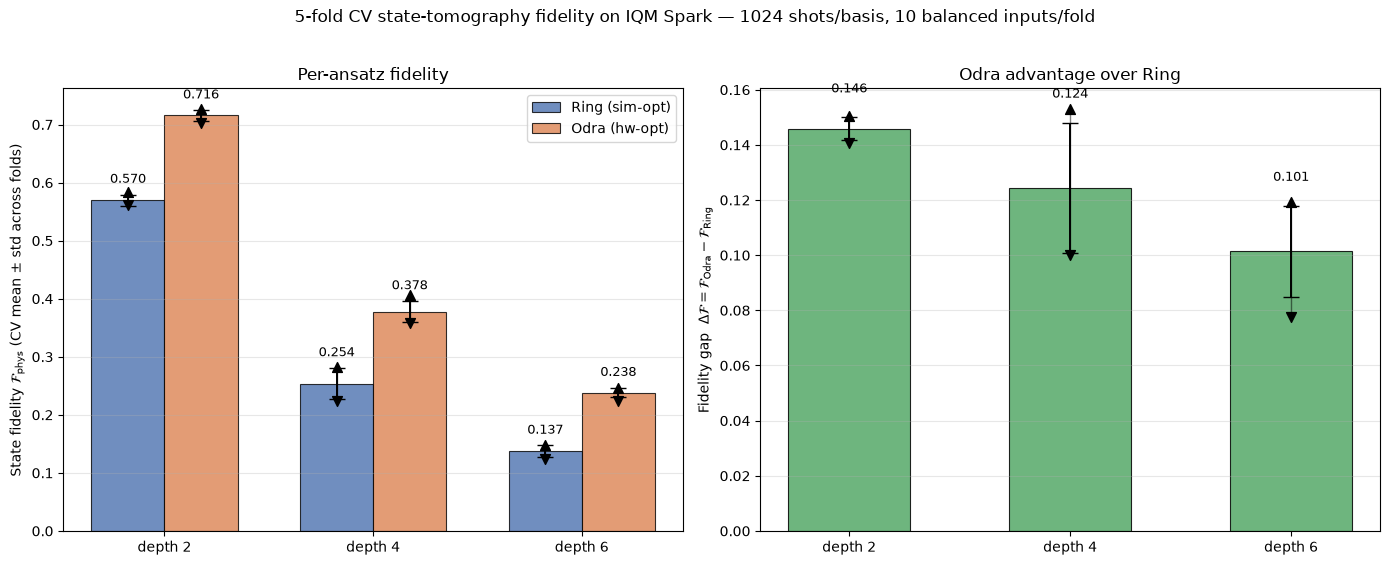

In [12]:
depths_sorted = sorted(cv_stats["depth"].unique())
ansatz_labels = [ANSATZ_CONFIG["ansatz_simulator"]["label"], ANSATZ_CONFIG["ansatz_odra"]["label"]]
colors = {"Ring (sim-opt)": "#4C72B0", "Odra (hw-opt)": "#DD8452"}

x = np.arange(len(depths_sorted))
width = 0.35
fig, (ax, ax_gap) = plt.subplots(1, 2, figsize=(14, 5.5))

for i, alabel in enumerate(ansatz_labels):
    sub = cv_stats[cv_stats["ansatz_label"] == alabel].set_index("depth").reindex(depths_sorted)
    means = sub["cv_mean_of_fold_means"].values
    stds = sub["cv_std_across_folds"].values
    mins = sub["cv_min_fold_mean"].values
    maxs = sub["cv_max_fold_mean"].values
    pos = x + (i - 0.5) * width
    ax.bar(pos, means, width, yerr=stds, capsize=6, color=colors[alabel], alpha=0.8,
           edgecolor="black", linewidth=0.8, label=alabel, error_kw={"elinewidth": 1.4, "ecolor": "black"})
    ax.vlines(pos, mins, maxs, color="black", linewidth=1.0, alpha=0.5)
    ax.scatter(pos, mins, marker="v", s=50, color="black", zorder=4)
    ax.scatter(pos, maxs, marker="^", s=50, color="black", zorder=4)
    for xi, m, sd in zip(pos, means, stds):
        ax.text(xi, m + sd + 0.015, f"{m:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f"depth {d}" for d in depths_sorted])
ax.set_ylabel(r"State fidelity $\mathcal{F}_{\mathrm{phys}}$ (CV mean $\pm$ std across folds)")
ax.set_title("Per-ansatz fidelity")
ax.legend(loc="upper right")
ax.grid(True, axis="y", alpha=0.3)

gap_sub = cv_gap_stats.set_index("depth").reindex(depths_sorted)
gap_means = gap_sub["cv_mean_gap"].values
gap_stds = gap_sub["cv_std_gap"].values
gap_mins = gap_sub["cv_min_gap"].values
gap_maxs = gap_sub["cv_max_gap"].values

ax_gap.bar(
    x, gap_means, width=0.55, yerr=gap_stds, capsize=6, color="#55A868", alpha=0.85,
    edgecolor="black", linewidth=0.8, error_kw={"elinewidth": 1.4, "ecolor": "black"},
)
ax_gap.vlines(x, gap_mins, gap_maxs, color="black", linewidth=1.0, alpha=0.5)
ax_gap.scatter(x, gap_mins, marker="v", s=50, color="black", zorder=4)
ax_gap.scatter(x, gap_maxs, marker="^", s=50, color="black", zorder=4)
for xi, m, sd in zip(x, gap_means, gap_stds):
    ax_gap.text(xi, m + sd + 0.008, f"{m:.3f}", ha="center", va="bottom", fontsize=9)

ax_gap.set_xticks(x)
ax_gap.set_xticklabels([f"depth {d}" for d in depths_sorted])
ax_gap.set_ylabel(r"Fidelity gap  $\Delta\mathcal{F} = \mathcal{F}_{\mathrm{Odra}} - \mathcal{F}_{\mathrm{Ring}}$")
ax_gap.set_title("Odra advantage over Ring")
ax_gap.grid(True, axis="y", alpha=0.3)

fig.suptitle(
    f"5-fold CV state-tomography fidelity on IQM Spark — "
    f"{SHOTS_PER_BASIS} shots/basis, {N_TOMOGRAPHY_INPUTS} balanced inputs/fold",
    y=1.02,
)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "full_odra_fidelity_cv_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Per-fold lines (optional diagnostic)

Shows how each fold's mean fidelity varies with depth — useful to spot outlier folds.

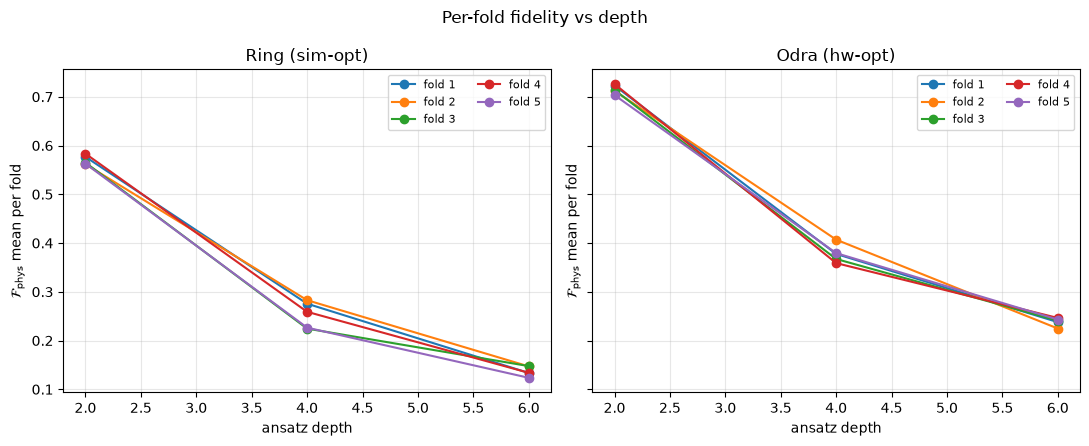

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, alabel in zip(axes, ansatz_labels):
    sub = fold_stats[fold_stats["ansatz_label"] == alabel]
    for fold in FOLDS:
        fsub = sub[sub["fold"] == fold].sort_values("depth")
        if fsub.empty:
            continue
        ax.plot(fsub["depth"], fsub["mean"], marker="o", label=f"fold {fold}")
    ax.set_title(alabel)
    ax.set_xlabel("ansatz depth")
    ax.set_ylabel(r"$\mathcal{F}_{\mathrm{phys}}$ mean per fold")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, ncol=2)
fig.suptitle("Per-fold fidelity vs depth")
plt.tight_layout()
plt.show()